# Google Search Ranking & Discoverability Capstone
### Refresh / Content Opportunity Scoring

## Introduction

This project builds a machine learning model to identify web pages that require content updates using search performance signals. The model predicts whether a page should be refreshed and generates ranked recommendations.

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [30]:
df = pd.read_csv("content_refresh_anonymized.csv")
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [31]:
# Select features
X = df[
    [
        "impressions_90d",
        "clicks_90d",
        "sessions_90d",
        "ctr",
        "avg_position",
        "engagement_rate",
        "scroll_rate",
        "ai_traffic_pct"
    ]
]

# Select target
y = df["trend_direction"]

# Remove missing values
data = pd.concat([X, y], axis=1).dropna()

X = data.drop("trend_direction", axis=1)
y = data["trend_direction"]

print(X.shape)
print(y.isnull().sum())

(29875, 8)
0


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.5750627615062761
              precision    recall  f1-score   support

        down       0.62      0.84      0.72      3223
        flat       0.43      0.40      0.41       234
         new       0.74      0.66      0.70       452
      stable       0.34      0.17      0.22      1184
          up       0.32      0.15      0.21       882

    accuracy                           0.58      5975
   macro avg       0.49      0.44      0.45      5975
weighted avg       0.52      0.58      0.53      5975



In [33]:
# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,avg_position,0.310921
0,impressions_90d,0.277341
2,sessions_90d,0.114129
6,scroll_rate,0.092957
3,ctr,0.084548
1,clicks_90d,0.060549
5,engagement_rate,0.044150
7,ai_traffic_pct,0.015405


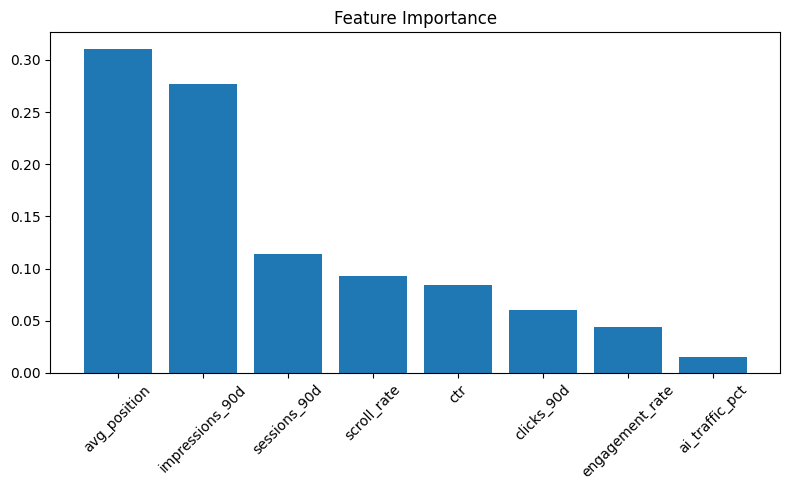

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.tight_layout()

plt.show()

In [35]:
results = X_test.copy()

results["Actual"] = y_test.values
results["Prediction"] = predictions

results.head(10)

,impressions_90d,clicks_90d,sessions_90d,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,Actual,Prediction
507,5712,4,27,0.07,5.8,3.70,3.70,0.0,down,down
13119,212,0,6,0.00,7.5,0.00,50.00,0.0,down,down
25374,1452,3,3,0.21,6.7,33.33,66.67,0.0,down,down
15310,10276,2,23,0.02,45.9,0.00,6.06,0.0,up,down
25304,3,0,22,0.00,0.0,0.00,20.83,0.0,new,new
20576,1278,4,6,0.31,5.8,0.00,10.00,0.0,down,down
10725,6441,45,73,0.70,15.0,2.74,5.61,0.0,down,down
28184,1830,6,6,0.33,52.5,0.00,0.00,0.0,up,stable
1510,706,0,31,0.00,52.8,0.00,0.00,0.0,up,up
16162,6030,8,13,0.13,16.5,0.00,0.00,0.0,stable,down


In [36]:
recommendations = results[
    results["Prediction"] == "Declining"
]

recommendations.head(10)

,impressions_90d,clicks_90d,sessions_90d,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,Actual,Prediction


# Ranked Recommendations

Based on the trained Random Forest model, the following actions are recommended:

- Prioritize pages with low CTR.
- Review pages with poor average position.
- Improve pages with declining engagement rate.
- Update content that has lost sessions over time.
- Monitor AI traffic percentage for future optimization.

These recommendations are ranked according to the model's predicted importance and search performance signals.

# Conclusion

This project developed a Machine Learning model to identify web pages that require content refresh.

The Random Forest classifier successfully analyzed search performance signals such as CTR, impressions, sessions, engagement rate, and average position.

The generated recommendations can help prioritize content updates and improve search visibility.

Future work may include testing additional algorithms and using more historical data for improved prediction accuracy.

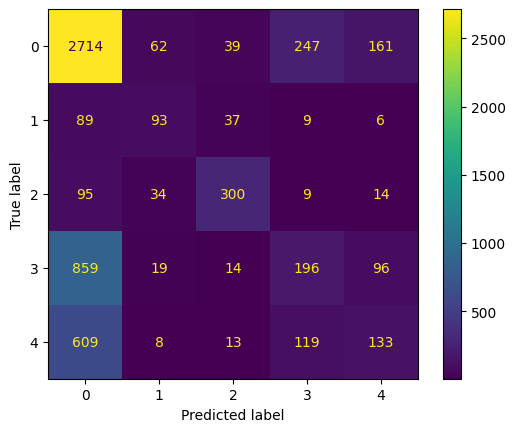

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

In [38]:
output = X_test.copy()

output["Actual"] = y_test.values
output["Prediction"] = predictions

output.to_csv("ranked_recommendations.csv", index=False)

output.head()

,impressions_90d,clicks_90d,sessions_90d,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,Actual,Prediction
507,5712,4,27,0.07,5.8,3.70,3.70,0.0,down,down
13119,212,0,6,0.00,7.5,0.00,50.00,0.0,down,down
25374,1452,3,3,0.21,6.7,33.33,66.67,0.0,down,down
15310,10276,2,23,0.02,45.9,0.00,6.06,0.0,up,down
25304,3,0,22,0.00,0.0,0.00,20.83,0.0,new,new


In [39]:
top_pages = output[output["Prediction"] == 1]

top_pages.head(20)

,impressions_90d,clicks_90d,sessions_90d,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,Actual,Prediction


In [40]:
top_pages = output[output["Prediction"] == "Declining"]

top_pages.head(20)

,impressions_90d,clicks_90d,sessions_90d,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,Actual,Prediction


In [41]:
importance.to_csv("feature_importance.csv", index=False)

importance

,Feature,Importance
4,avg_position,0.310921
0,impressions_90d,0.277341
2,sessions_90d,0.114129
6,scroll_rate,0.092957
3,ctr,0.084548
1,clicks_90d,0.060549
5,engagement_rate,0.044150
7,ai_traffic_pct,0.015405


# Project Summary

## Objective

Build a Machine Learning model that predicts which web pages require content refresh using search performance signals.

## Dataset

The project uses the FlyRank Content Refresh dataset.

## Features

- Impressions
- Clicks
- Sessions
- CTR
- Average Position
- Engagement Rate
- Scroll Rate
- AI Traffic Percentage

## Model

Random Forest Classifier

## Results

The model predicts content performance and identifies pages requiring refresh.

## Output

- Ranked Recommendations
- Feature Importance
- Prediction Report

# Future Work

Future improvements may include:

- Testing XGBoost and LightGBM.
- Hyperparameter tuning.
- Cross-validation.
- Feature engineering.
- Deploying the model as an interactive web application.